In [7]:
from LatentDistanceModel import LatentDistanceModel
from utils import (
    get_initial_parameters,
    load_MNIST,
    load_s_hole,
    load_swissroll,
    load_mammoth,
    load_pendigits,
    sample_edges,
)
import torch
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def continuous_to_integer_bins(t):
    n_bins = int(np.floor(t.max()) - np.ceil(t.min())) + 1
    return np.digitize(t, bins=np.linspace(t.min(), t.max(), num=n_bins))

# Load data
dataset = "swissroll"
discretize = True

match dataset:
    case "swissroll":
        samples = 5000
        X, t = load_swissroll(n_samples=samples)
        if discretize == True and 't' in locals():
            y = continuous_to_integer_bins(t)  # Er en måde at få reelle labels ud af kontinuerte data, som er nødvendigt for at kunne evaluere på triplet testene.
        else:
            y = t

    case "s_hole":
        samples = 5000
        X, t = load_s_hole(n_samples=samples)
        if discretize == True and 't' in locals():
            y = continuous_to_integer_bins(t)  # Er en måde at få reelle labels ud af kontinuerte data, som er nødvendigt for at kunne evaluere på triplet testene.
        else:
            y = t

    case "mammoth":
        X, y = load_mammoth(subset_percent=0.01)  # y= None
        discretize = False
        samples = X.shape[0]
    case "mnist":
        X, y = load_MNIST(subset_percent=0.1)
        discretize = False
        samples = X.shape[0]

        # t == kontinuerte labels, og y == diskrete labels

if isinstance(X, torch.Tensor):
    X_numpy = X.numpy()
else:
    X_numpy = X
N, D = X.shape
print('data rows,cols:', N, D)


data rows,cols: 5000 3


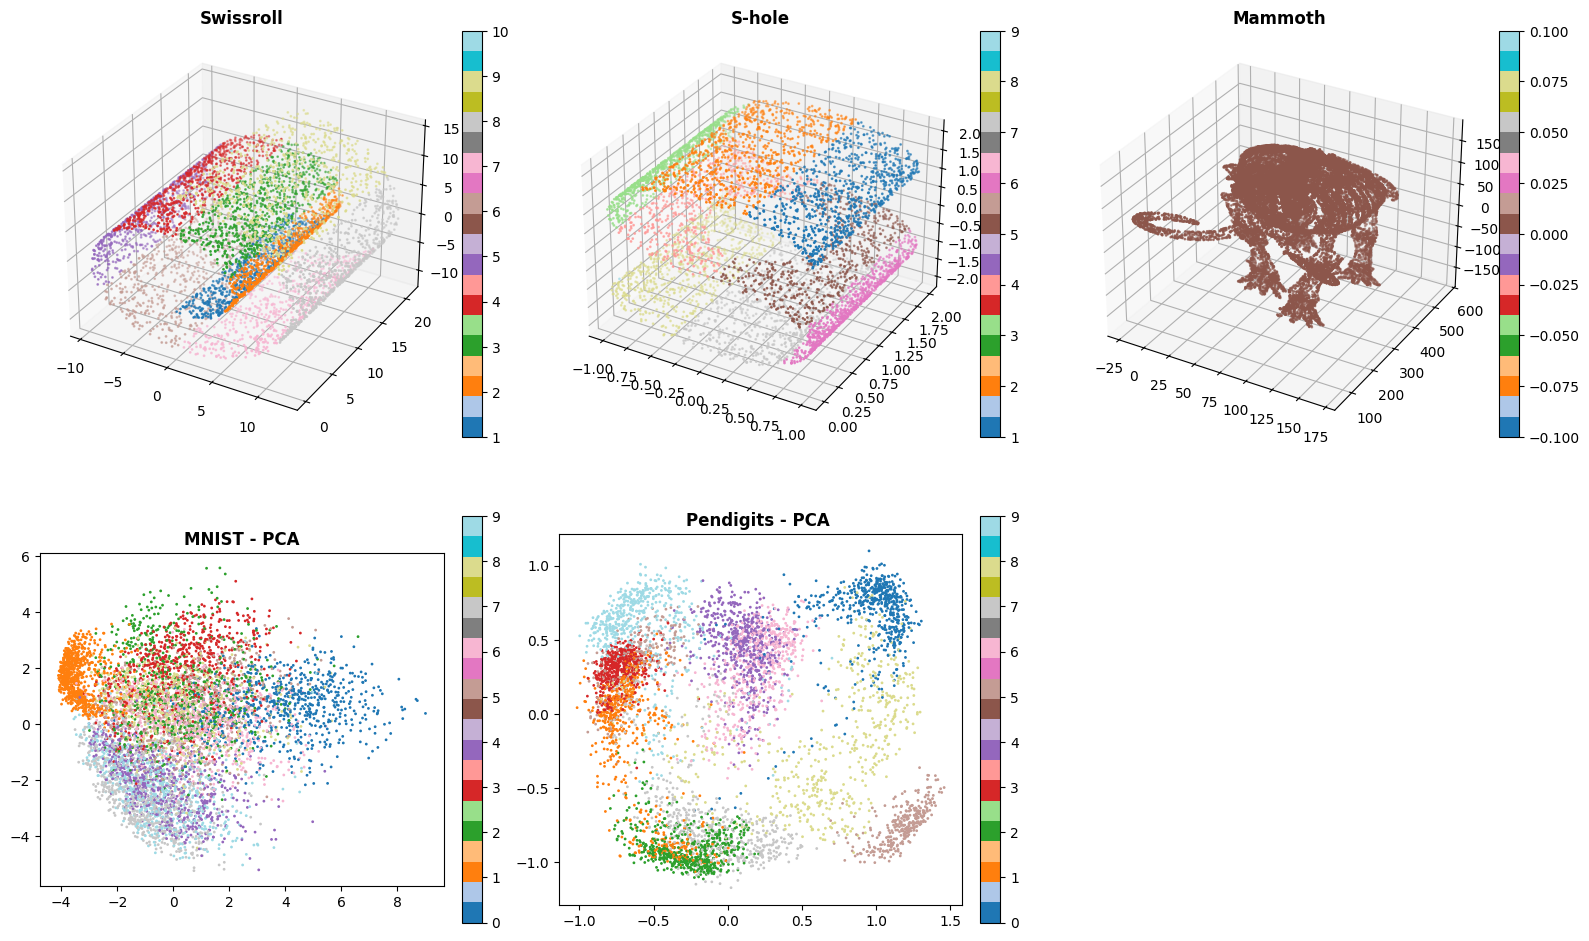


Dataset Summary:
Swissroll: torch.Size([6000, 3]), labels: 10 bins
S-hole: torch.Size([5701, 3]), labels: 9 bins
Mammoth: torch.Size([24994, 3]), labels: 1 classes
MNIST: torch.Size([7000, 784]), labels: 10 classes
Pendigits: torch.Size([5496, 16]), labels: 10 classes


In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def continuous_to_integer_bins(t):
    n_bins = int(np.floor(t.max()) - np.ceil(t.min())) + 1
    return np.digitize(t, bins=np.linspace(t.min(), t.max(), num=n_bins))


# Load all five datasets with labels.
# Swissroll and s-hole use discretized labels from the continuous parameter.
datasets_to_plot = {}

X_swissroll, t_swissroll = load_swissroll(n_samples=6000)
y_swissroll = continuous_to_integer_bins(t_swissroll)
datasets_to_plot["Swissroll"] = {
    "X": X_swissroll.numpy(),
    "y": y_swissroll,
    "kind": "3d",
    "labels": True,
}

X_s_hole, t_s_hole = load_s_hole(n_samples=6000)
y_s_hole = continuous_to_integer_bins(t_s_hole)
datasets_to_plot["S-hole"] = {
    "X": X_s_hole.numpy(),
    "y": y_s_hole,
    "kind": "3d",
    "labels": True,
}

X_mammoth, y_mammoth = load_mammoth(subset_percent=0.025)
datasets_to_plot["Mammoth"] = {
    "X": X_mammoth.numpy(),
    "y": y_mammoth.numpy().reshape(-1),
    "kind": "3d",
    "labels": True,
}

X_mnist, y_mnist = load_MNIST(subset_percent=0.1)
pca_mnist = PCA(n_components=2)
X_mnist_2d = pca_mnist.fit_transform(X_mnist.numpy())
datasets_to_plot["MNIST - PCA"] = {
    "X": X_mnist_2d,
    "y": y_mnist.numpy().reshape(-1),
    "kind": "2d",
    "labels": True,
}

X_pendigits, y_pendigits = load_pendigits(subset_percent=0.5)
pca_pendigits = PCA(n_components=2)
X_pendigits_2d = pca_pendigits.fit_transform(X_pendigits.numpy())
datasets_to_plot["Pendigits - PCA "] = {
    "X": X_pendigits_2d,
    "y": y_pendigits.numpy().reshape(-1),
    "kind": "2d",
    "labels": True,
}

# Create visualization
fig = plt.figure(figsize=(16, 10))

for plot_idx, (name, dataset_info) in enumerate(datasets_to_plot.items(), start=1):
    data = dataset_info["X"]
    labels = dataset_info["y"]

    if dataset_info["kind"] == "3d":
        ax = fig.add_subplot(2, 3, plot_idx, projection="3d")
        scatter = ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=labels, s=1, cmap="tab20")
    else:
        ax = fig.add_subplot(2, 3, plot_idx)
        scatter = ax.scatter(data[:, 0], data[:, 1], c=labels, s=1, cmap="tab20")
        ax.set_aspect("equal", adjustable="box")

    ax.set_title(name, fontsize=12, fontweight="bold")
    if dataset_info["labels"]:
        plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\nDataset Summary:")
print(f"Swissroll: {X_swissroll.shape}, labels: {len(np.unique(y_swissroll))} bins")
print(f"S-hole: {X_s_hole.shape}, labels: {len(np.unique(y_s_hole))} bins")
print(f"Mammoth: {X_mammoth.shape}, labels: {len(np.unique(y_mammoth))} classes")
print(f"MNIST: {X_mnist.shape}, labels: {len(np.unique(y_mnist))} classes")
print(f"Pendigits: {X_pendigits.shape}, labels: {len(np.unique(y_pendigits))} classes")